# Bronnenmatch — Geluidsmeter

Vergelijking gemeten geluid vs. referentiedata (NWB, BGT, CVGG).  
**Let op:** dB(A)-waarden zijn *indicatief* — ongekalibreerd prototype.

In [1]:
import os, sys, json, math
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point

# Zorg dat werkdirectory altijd de repo-root is, ongeacht hoe het notebook wordt gestart
# Notebooks liggen in <repo>/notebooks/, dus de repo-root is altijd één niveau hoger.
_nb_dir = Path(os.path.abspath(""))
REPO_ROOT = (_nb_dir / "..").resolve() if _nb_dir.name == "notebooks" else _nb_dir
os.chdir(REPO_ROOT)

sys.path.insert(0, str(REPO_ROOT / "src"))
from geluidsmeter.config import load_config, load_private_location
from geluidsmeter.source_match import estimate_dba, check_norm, identify_sources, match_cvgg
from geluidsmeter.aggregate import load_features

config = load_config("core/config.yaml")
loc = load_private_location(config)
offset = config["measurement"].get("calibration_offset_db", 0)
precision_m = config["location"]["public_location_precision_m"]

def _round_location(lat, lon, precision_m):
    deg = precision_m / 111_000
    decimals = max(0, -int(math.floor(math.log10(deg))))
    return round(lat, decimals), round(lon, decimals)

lat_pub, lon_pub = _round_location(loc["lat"], loc["lon"], precision_m)
location = Point(lon_pub, lat_pub)

print(f"Locatie (afgerond): {lat_pub:.4f}, {lon_pub:.4f}")
print(f"Kalibratie offset: {offset} dB (0 = ongekalibreerd)")


Locatie (afgerond): 51.0000, 5.0000
Kalibratie offset: 0 dB (0 = ongekalibreerd)


## 1. Meting vs. model

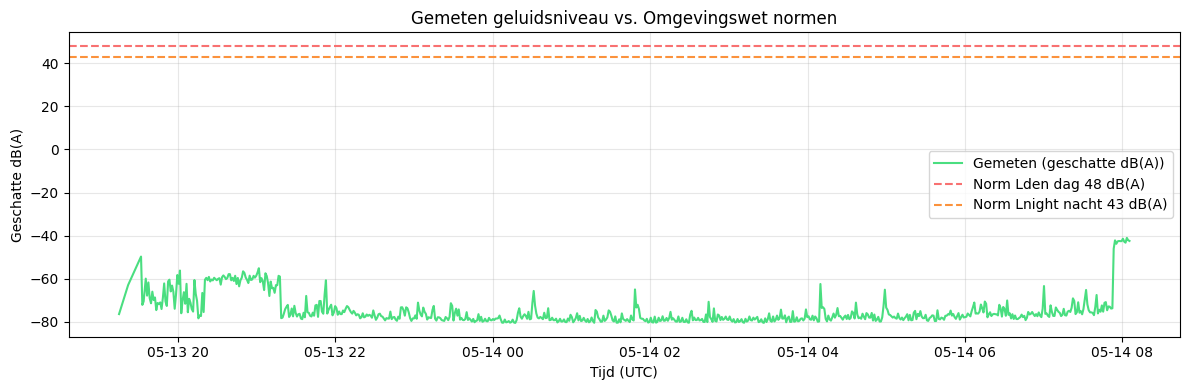

Totaal 754 metingen


In [2]:
raw_dir = Path(config["outputs"]["raw_features_dir"])
df = load_features(raw_dir)

if df.empty:
    print("Geen meetdata gevonden.")
else:
    df["dba_est"] = df["rms_dbfs"].apply(lambda x: estimate_dba(x, offset))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["ts"], df["dba_est"], label="Gemeten (geschatte dB(A))", color="#4ade80", lw=1.5)
    ax.axhline(48, color="#f87171", ls="--", label="Norm Lden dag 48 dB(A)")
    ax.axhline(43, color="#fb923c", ls="--", label="Norm Lnight nacht 43 dB(A)")
    ax.set_ylabel("Geschatte dB(A)")
    ax.set_xlabel("Tijd (UTC)")
    ax.set_title("Gemeten geluidsniveau vs. Omgevingswet normen")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("notebooks/meting_vs_norm.png", dpi=120)
    plt.show()
    print(f"Totaal {len(df)} metingen")


## 2. Bronidentificatie

In [3]:
nwb_path = Path(config["outputs"]["external_dir"]) / "atlas" / "nwb_wegvakken.geojson"
if nwb_path.exists():
    nwb_gdf = gpd.read_file(nwb_path)
    sources = identify_sources(nwb_gdf)
    print(f"Dominante bron: {sources['dominant_source']}")
    print(f"Wegvakken in bbox: {sources['weg_count']} (waarvan rijkswegen: {sources.get('rijksweg_count', 0)})")
    print(f"Weg gedetecteerd: {sources['weg_detected']}")

    cats = {}
    if "wegbeheerdersoort" in nwb_gdf.columns:
        cats = nwb_gdf["wegbeheerdersoort"].value_counts().to_dict()

    if cats:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.barh(list(cats.keys()), list(cats.values()), color="#3b82f6")
        ax.set_xlabel("Aantal wegvakken")
        ax.set_title("Wegbeheer in bbox (bronidentificatie)")
        plt.tight_layout()
        plt.savefig("notebooks/bronidentificatie.png", dpi=120)
        plt.show()
    else:
        print("Geen wegbeheerdersoort kolom aanwezig — probeer 03_fetch_external.py opnieuw.")
else:
    print("NWB data niet gevonden — voer eerst 03_fetch_external.py uit.")


NWB data niet gevonden — voer eerst 03_fetch_external.py uit.


## 3. Normtoetsing

In [4]:
if not df.empty:
    df["dba_est"] = df["rms_dbfs"].apply(lambda x: estimate_dba(x, offset))
    nacht_df = df[~df["hour"].isin(range(7, 23))]

    lden_est = float(df["dba_est"].mean()) if not df.empty else None
    lnight_est = float(nacht_df["dba_est"].mean()) if not nacht_df.empty else None

    if lden_est is not None and lnight_est is not None:
        norm = check_norm(lden_est, lnight_est)
        print("=== Normtoetsing (prototype — ongekalibreerd) ===")
        for k, v in norm.items():
            print(f"  {k}: {v}")

        tabel = pd.DataFrame([
            {"Periode": "Etmaal (Lden)", "Gemeten dB(A)": norm["lden_db"],
             "Norm dB(A)": norm["lden_norm"], "Delta": norm["lden_delta"],
             "Status": norm["lden_status"]},
            {"Periode": "Nacht (Lnight)", "Gemeten dB(A)": norm["lnight_db"],
             "Norm dB(A)": norm["lnight_norm"], "Delta": norm["lnight_delta"],
             "Status": norm["lnight_status"]},
        ])
        try:
            display(tabel)
        except NameError:
            print(tabel.to_string())
    else:
        print("Onvoldoende data voor normtoetsing (dag + nacht metingen nodig).")
else:
    print("Geen meetdata beschikbaar.")


=== Normtoetsing (prototype — ongekalibreerd) ===
  lden_db: -74.8
  lden_norm: 48.0
  lden_delta: -122.8
  lden_status: ok
  lnight_db: -77.8
  lnight_norm: 43.0
  lnight_delta: -120.8
  lnight_status: ok


,Periode,Gemeten dB(A),Norm dB(A),Delta,Status
0,Etmaal (Lden),-74.8,48.0,-122.8,ok
1,Nacht (Lnight),-77.8,43.0,-120.8,ok
